# Avaliação A3 - Comitê de Classificadores para Detecção de Fraude

Universidade São Judas Tadeu  
Disciplina: Inteligência Artificial

Este notebook desenvolve um pipeline completo de aprendizado supervisionado para classificar transações financeiras como fraudulentas ou não fraudulentas. O projeto inclui análise exploratória, pré-processamento, treinamento de três classificadores individuais e construção de um comitê por votação majoritária.

## 1. Importação das bibliotecas

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import VotingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

## 2. Carregamento da base de dados

A base utilizada é `synthetic_fraud_dataset.csv`, composta por transações financeiras sintéticas. Ela é adequada para um problema de classificação binária porque possui a variável alvo `is_fraud`, que indica se a transação é fraudulenta.

In [2]:
DATA_PATH = Path("data") / "synthetic_fraud_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


## 3. Análise exploratória inicial

In [3]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

df.info()

Linhas: 10000
Colunas: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values.to_frame("valores_ausentes")

,valores_ausentes
transaction_id,0
user_id,0
amount,0
transaction_type,0
merchant_category,0
country,0
hour,0
device_risk_score,0
ip_risk_score,0
is_fraud,0


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,NaN,NaN,NaN,4999.5,2886.89568,0.0,2499.75,4999.5,7499.25,9999.0
user_id,10000.0,NaN,NaN,NaN,500.0587,288.328495,0.0,247.0,503.0,750.25,999.0
amount,10000.0,NaN,NaN,NaN,178.142763,531.64795,1.0,65.084753,101.68651,138.280872,11628.213881
transaction_type,10000,4,POS,2568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,10000,5,Food,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,10000,6,US,2050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,10000.0,NaN,NaN,NaN,14.2471,5.347383,0.0,10.0,14.0,19.0,23.0
device_risk_score,10000.0,NaN,NaN,NaN,0.183773,0.177381,0.00003,0.075721,0.156583,0.234939,0.998737
ip_risk_score,10000.0,NaN,NaN,NaN,0.184669,0.175772,0.000009,0.077762,0.15829,0.236968,0.999603
is_fraud,10000.0,NaN,NaN,NaN,0.05,0.217956,0.0,0.0,0.0,0.0,1.0


In [6]:
target_summary = pd.DataFrame({
    "quantidade": df["is_fraud"].value_counts().sort_index(),
    "percentual": (df["is_fraud"].value_counts(normalize=True).sort_index() * 100).round(2),
})

target_summary

,quantidade,percentual
is_fraud,,
0,9500,95.0
1,500,5.0


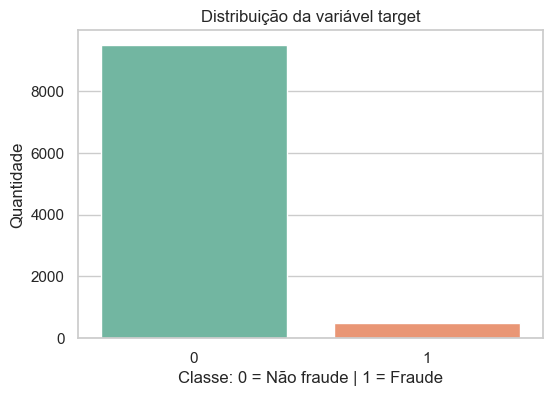

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_fraud", hue="is_fraud", palette="Set2", legend=False)
plt.title("Distribuição da variável target")
plt.xlabel("Classe: 0 = Não fraude | 1 = Fraude")
plt.ylabel("Quantidade")
plt.show()

In [8]:
categorical_columns = ["transaction_type", "merchant_category", "country"]

for column in categorical_columns:
    display(df[column].value_counts().to_frame("quantidade"))

,quantidade
transaction_type,
POS,2568
ATM,2529
QR,2506
Online,2397


,quantidade
merchant_category,
Food,2023
Travel,2015
Electronics,2007
Clothing,1982
Grocery,1973


,quantidade
country,
US,2050
FR,2027
UK,1965
DE,1930
TR,1928
NG,100


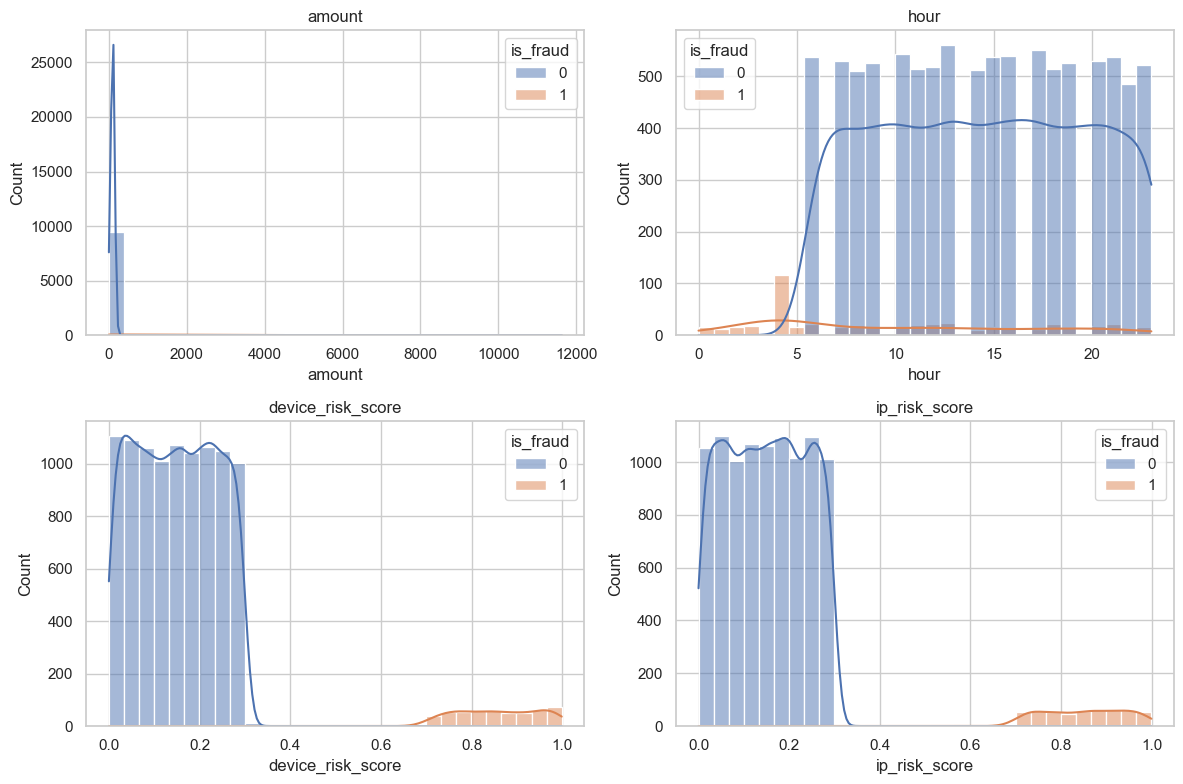

In [9]:
numeric_columns_preview = ["amount", "hour", "device_risk_score", "ip_risk_score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, column in zip(axes, numeric_columns_preview):
    sns.histplot(data=df, x=column, hue="is_fraud", bins=30, kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

## 4. Definição do problema

O problema consiste em prever se uma transação é fraudulenta.

- Variável target: `is_fraud`
- Classe 0: transação não fraudulenta
- Classe 1: transação fraudulenta

As colunas `transaction_id` e `user_id` foram removidas porque são identificadores. Elas não representam características gerais da transação para inferência.

In [10]:
target_column = "is_fraud"
id_columns = ["transaction_id", "user_id"]

X = df.drop(columns=[target_column] + id_columns)
y = df[target_column]

print("Features utilizadas:")
for column in X.columns:
    print(f"- {column}")

Features utilizadas:
- amount
- transaction_type
- merchant_category
- country
- hour
- device_risk_score
- ip_risk_score


## 5. Separação em treino e teste

A divisão usa 80% dos dados para treino e 20% para teste. A estratificação preserva a proporção de fraudes e não fraudes em ambos os conjuntos.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Proporção treino/teste: {1 - TEST_SIZE:.0%} / {TEST_SIZE:.0%}")
print("Treino:", X_train.shape)
print(y_train.value_counts().sort_index())
print("\nTeste:", X_test.shape)
print(y_test.value_counts().sort_index())

Proporção treino/teste: 80% / 20%
Treino: (8000, 7)
is_fraud
0    7600
1     400
Name: count, dtype: int64

Teste: (2000, 7)
is_fraud
0    1900
1     100
Name: count, dtype: int64


## 6. Pré-processamento

O pipeline aplica tratamento de valores ausentes, padroniza as variáveis numéricas e codifica as variáveis categóricas com one-hot encoding.

In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)
print("Formato após o pré-processamento:", X_train_processed.shape)

Features numéricas: ['amount', 'hour', 'device_risk_score', 'ip_risk_score']
Features categóricas: ['transaction_type', 'merchant_category', 'country']
Formato após o pré-processamento: (8000, 19)


## 7. Balanceamento do conjunto de treino

A base é desbalanceada, com cerca de 5% de fraudes. Para reduzir o viés dos modelos em favor da classe majoritária, foi aplicado oversampling simples apenas no conjunto de treino. O conjunto de teste permanece com a distribuição original para avaliar os modelos em uma situação mais realista.

In [13]:
def oversample_minority_class(X_data, y_data, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_data)

    classes, counts = np.unique(y_array, return_counts=True)
    majority_count = counts.max()
    sampled_indices = []

    for class_value in classes:
        class_indices = np.flatnonzero(y_array == class_value)
        extra_indices = rng.choice(
            class_indices,
            size=majority_count - len(class_indices),
            replace=True,
        )
        sampled_indices.extend(class_indices.tolist())
        sampled_indices.extend(extra_indices.tolist())

    sampled_indices = np.array(sampled_indices)
    rng.shuffle(sampled_indices)
    return X_data[sampled_indices], y_array[sampled_indices]

X_train_balanced, y_train_balanced = oversample_minority_class(X_train_processed, y_train)

pd.Series(y_train_balanced).value_counts().sort_index().to_frame("quantidade")

,quantidade
0,7600
1,7600


## 8. Modelagem: classificadores individuais

Foram treinados três algoritmos diferentes:

1. Rede Neural (`MLPClassifier`)
2. Árvore de Decisão (`DecisionTreeClassifier`)
3. Regressão Logística (`LogisticRegression`)

Todos os modelos foram treinados com os mesmos dados pré-processados e balanceados.

In [14]:
models = {
    "Rede Neural": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    ),
    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    ),
    "Regressão Logística": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    print(f"Modelo treinado: {name}")

Modelo treinado: Rede Neural
Modelo treinado: Árvore de Decisão
Modelo treinado: Regressão Logística


## 9. Avaliação dos modelos individuais

As métricas utilizadas foram acurácia, precisão, recall e F1-score. Em problemas de fraude, recall e F1-score são especialmente importantes porque a classe fraude é minoritária.

In [15]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    metrics = {
        "modelo": name,
        "acurácia": accuracy_score(y_eval, y_pred),
        "precisão": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1_score": f1_score(y_eval, y_pred, zero_division=0),
    }
    return metrics, y_pred

individual_results = []
individual_predictions = {}

for name, model in models.items():
    metrics, predictions = evaluate_model(name, model, X_test_processed, y_test)
    individual_results.append(metrics)
    individual_predictions[name] = predictions

individual_results_df = pd.DataFrame(individual_results)
individual_results_df.round(4)

,modelo,acurácia,precisão,recall,f1_score
0,Rede Neural,1.0,1.0,1.0,1.0
1,Árvore de Decisão,1.0,1.0,1.0,1.0
2,Regressão Logística,1.0,1.0,1.0,1.0


In [16]:
for name, predictions in individual_predictions.items():
    print(f"\nRelatório de classificação - {name}")
    print(classification_report(
        y_test,
        predictions,
        target_names=["Não fraude", "Fraude"],
        zero_division=0,
    ))


Relatório de classificação - Rede Neural
              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Relatório de classificação - Árvore de Decisão
              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Relatório de classificação - Regressão Logística
              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.0

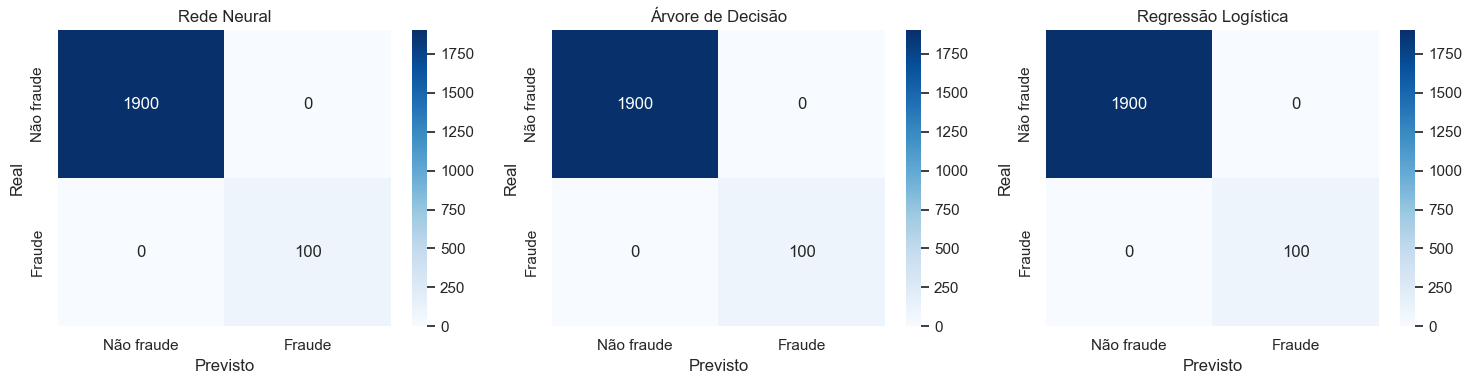

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, predictions) in zip(axes, individual_predictions.items()):
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Não fraude", "Fraude"],
        yticklabels=["Não fraude", "Fraude"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

## 10. Construção do comitê de classificadores

O comitê foi construído com votação majoritária (`hard voting`). Essa estratégia foi escolhida porque combina decisões de modelos com características diferentes: a rede neural captura relações não lineares, a árvore de decisão cria regras interpretáveis e a regressão logística oferece uma fronteira linear simples e estável.

In [18]:
committee = VotingClassifier(
    estimators=[
        ("rede_neural", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
        ("arvore_decisao", DecisionTreeClassifier(
            max_depth=5,
            random_state=RANDOM_STATE,
        )),
        ("regressao_logistica", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ],
    voting="hard",
)

committee.fit(X_train_balanced, y_train_balanced)
committee_metrics, committee_predictions = evaluate_model(
    "Comitê de Classificadores",
    committee,
    X_test_processed,
    y_test,
)

pd.DataFrame([committee_metrics]).round(4)

,modelo,acurácia,precisão,recall,f1_score
0,Comitê de Classificadores,1.0,1.0,1.0,1.0


In [19]:
print("Relatório de classificação - Comitê de Classificadores")
print(classification_report(
    y_test,
    committee_predictions,
    target_names=["Não fraude", "Fraude"],
    zero_division=0,
))

Relatório de classificação - Comitê de Classificadores
              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



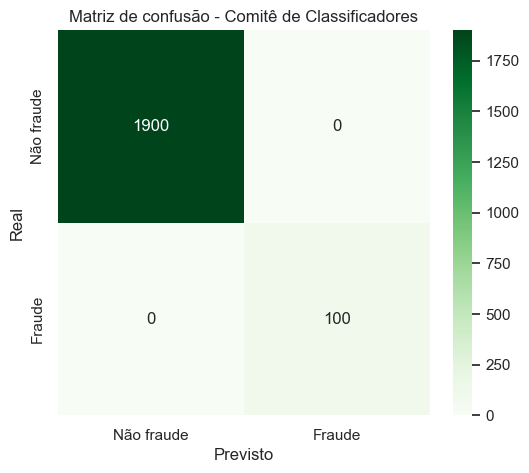

In [20]:
committee_matrix = confusion_matrix(y_test, committee_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    committee_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Não fraude", "Fraude"],
    yticklabels=["Não fraude", "Fraude"],
)
plt.title("Matriz de confusão - Comitê de Classificadores")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 11. Comparação dos resultados

In [21]:
comparison_df = pd.concat(
    [individual_results_df, pd.DataFrame([committee_metrics])],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values(
    by=["f1_score", "recall", "precisão", "acurácia"],
    ascending=False,
).reset_index(drop=True)

comparison_df.round(4)

,modelo,acurácia,precisão,recall,f1_score
0,Rede Neural,1.0,1.0,1.0,1.0
1,Árvore de Decisão,1.0,1.0,1.0,1.0
2,Regressão Logística,1.0,1.0,1.0,1.0
3,Comitê de Classificadores,1.0,1.0,1.0,1.0


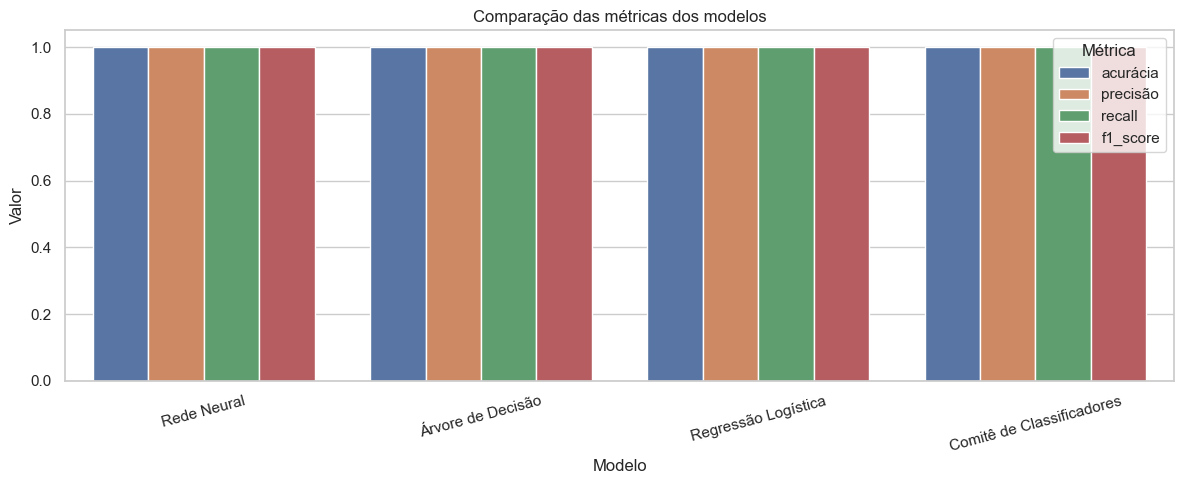

In [22]:
metrics_to_plot = ["acurácia", "precisão", "recall", "f1_score"]
plot_df = comparison_df.melt(id_vars="modelo", value_vars=metrics_to_plot, var_name="métrica", value_name="valor")

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="modelo", y="valor", hue="métrica")
plt.ylim(0, 1.05)
plt.title("Comparação das métricas dos modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

In [23]:
best_individual_model = individual_results_df.sort_values(
    by=["f1_score", "recall", "precisão", "acurácia"],
    ascending=False,
).iloc[0]

committee_row = pd.Series(committee_metrics)

print(f"Melhor modelo individual: {best_individual_model['modelo']}")
print(f"F1-score do melhor modelo individual: {best_individual_model['f1_score']:.4f}")
print(f"F1-score do comitê: {committee_row['f1_score']:.4f}")

if committee_row["f1_score"] > best_individual_model["f1_score"]:
    print("O comitê apresentou melhora em relação ao melhor modelo individual.")
elif committee_row["f1_score"] == best_individual_model["f1_score"]:
    print("O comitê empatou com o melhor modelo individual.")
else:
    print("O comitê não superou o melhor modelo individual nesta base.")

Melhor modelo individual: Rede Neural
F1-score do melhor modelo individual: 1.0000
F1-score do comitê: 1.0000
O comitê empatou com o melhor modelo individual.


## 12. Teste complementar sem variáveis de risco

Como todos os modelos apresentaram desempenho perfeito, foi realizado um teste adicional removendo `device_risk_score` e `ip_risk_score`. Essas variáveis são muito informativas e podem tornar a separação entre fraude e não fraude simples demais em uma base sintética.

Esse teste não substitui o modelo principal. Ele serve para analisar a dependência dos modelos em relação aos escores de risco e fortalecer a discussão crítica do projeto.

In [24]:
risk_features = ["device_risk_score", "ip_risk_score"]
X_without_risk = X.drop(columns=risk_features)

X_train_wr, X_test_wr, y_train_wr, y_test_wr = train_test_split(
    X_without_risk,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features_wr = X_without_risk.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_wr = X_without_risk.select_dtypes(include=["object"]).columns.tolist()

preprocessor_without_risk = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_wr),
        ("cat", categorical_transformer, categorical_features_wr),
    ]
)

X_train_wr_processed = preprocessor_without_risk.fit_transform(X_train_wr)
X_test_wr_processed = preprocessor_without_risk.transform(X_test_wr)
X_train_wr_balanced, y_train_wr_balanced = oversample_minority_class(X_train_wr_processed, y_train_wr)

models_without_risk = {
    "Rede Neural sem scores de risco": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    ),
    "Árvore de Decisão sem scores de risco": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    ),
    "Regressão Logística sem scores de risco": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
}

results_without_risk = []

for name, model in models_without_risk.items():
    model.fit(X_train_wr_balanced, y_train_wr_balanced)
    metrics, _ = evaluate_model(name, model, X_test_wr_processed, y_test_wr)
    results_without_risk.append(metrics)

results_without_risk_df = pd.DataFrame(results_without_risk)
results_without_risk_df.round(4)

,modelo,acurácia,precisão,recall,f1_score
0,Rede Neural sem scores de risco,0.9745,0.6870,0.90,0.7792
1,Árvore de Decisão sem scores de risco,0.9990,1.0000,0.98,0.9899
2,Regressão Logística sem scores de risco,0.9780,0.7545,0.83,0.7905


In [25]:
main_summary = comparison_df[["modelo", "acurácia", "precisão", "recall", "f1_score"]].copy()
main_summary["cenário"] = "Com scores de risco"

risk_summary = results_without_risk_df[["modelo", "acurácia", "precisão", "recall", "f1_score"]].copy()
risk_summary["cenário"] = "Sem scores de risco"

risk_comparison_df = pd.concat([main_summary, risk_summary], ignore_index=True)
risk_comparison_df[["cenário", "modelo", "acurácia", "precisão", "recall", "f1_score"]].round(4)

,cenário,modelo,acurácia,precisão,recall,f1_score
0,Com scores de risco,Rede Neural,1.0000,1.0000,1.00,1.0000
1,Com scores de risco,Árvore de Decisão,1.0000,1.0000,1.00,1.0000
2,Com scores de risco,Regressão Logística,1.0000,1.0000,1.00,1.0000
3,Com scores de risco,Comitê de Classificadores,1.0000,1.0000,1.00,1.0000
4,Sem scores de risco,Rede Neural sem scores de risco,0.9745,0.6870,0.90,0.7792
5,Sem scores de risco,Árvore de Decisão sem scores de risco,0.9990,1.0000,0.98,0.9899
6,Sem scores de risco,Regressão Logística sem scores de risco,0.9780,0.7545,0.83,0.7905


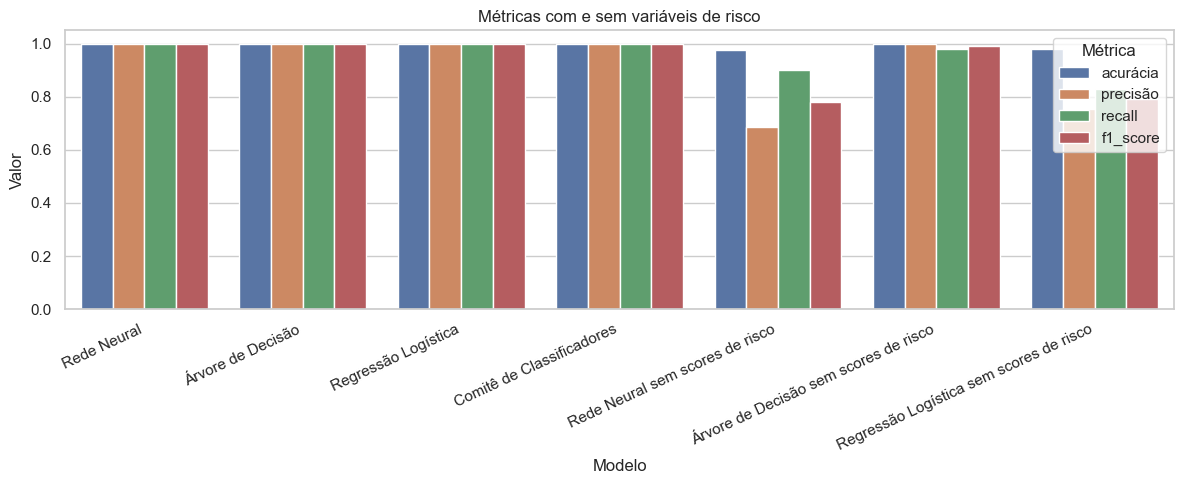

In [26]:
plot_risk_df = risk_comparison_df.melt(
    id_vars=["cenário", "modelo"],
    value_vars=["acurácia", "precisão", "recall", "f1_score"],
    var_name="métrica",
    value_name="valor",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_risk_df, x="modelo", y="valor", hue="métrica")
plt.ylim(0, 1.05)
plt.title("Métricas com e sem variáveis de risco")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# --- EXECUÇÃO DO TESTE 1: Dado Existente ---
# 1. Pega a primeira linha de X_test (com os textos originais)
dataset_teste_1 = X_test.iloc[[0]].copy()

print("--- TESTE 1: Dado Existente ---")
display(dataset_teste_1)

# 2. Transforma o texto em número usando o seu preprocessor original
dados_processados_1 = preprocessor.transform(dataset_teste_1)

# 3. Faz a previsão usando o seu comitê (committee)
resultado_1 = committee.predict(dados_processados_1)
print(f"Previsão do Teste 1 (0 = Não Fraude, 1 = Fraude): {resultado_1}\n")
print("-" * 50)


# --- EXECUÇÃO DO TESTE 2: Dados Inéditos ---
# 1. Cria o dado inédito alterando o valor da primeira coluna
dataset_teste_2 = X_test.iloc[[0]].copy()
primeira_coluna = dataset_teste_2.columns[0]
dataset_teste_2[primeira_coluna] = [99999.0] 

print(f"\n--- TESTE 2: Dados Inéditos (Alterado valor na coluna '{primeira_coluna}') ---")
display(dataset_teste_2)

# 2. Passa o dado inédito também pelo preprocessor
dados_processados_2 = preprocessor.transform(dataset_teste_2)

# 3. Faz a previsão com o comitê
resultado_2 = committee.predict(dados_processados_2)
print(f"Previsão do Teste 2 (0 = Não Fraude, 1 = Fraude): {resultado_2}")

--- TESTE 1: Dado Existente ---


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score
1233,36.086869,QR,Clothing,TR,21,0.271625,0.27774


Previsão do Teste 1 (0 = Não Fraude, 1 = Fraude): [0]

--------------------------------------------------

--- TESTE 2: Dados Inéditos (Alterado valor na coluna 'amount') ---


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score
1233,99999.0,QR,Clothing,TR,21,0.271625,0.27774


Previsão do Teste 2 (0 = Não Fraude, 1 = Fraude): [1]


## 13. Discussão

A base apresenta forte desbalanceamento, pois a classe fraude representa uma parcela pequena das transações. Por esse motivo, a acurácia não deve ser analisada sozinha. Em um problema de detecção de fraude, recall e F1-score são métricas mais relevantes, porque indicam a capacidade do modelo de encontrar fraudes sem ignorar a precisão das previsões.

Os três classificadores escolhidos têm perfis diferentes. A rede neural é capaz de modelar relações não lineares, a Árvore de Decisão facilita a interpretação por regras e a Regressão Logística funciona como um modelo linear simples e eficiente. O comitê combina essas decisões por votação majoritária, buscando uma decisão final mais robusta.

No cenário principal, todos os modelos atingiram métricas perfeitas. Esse resultado é explicado pela natureza sintética da base e pela presença de variáveis muito fortes, especialmente `device_risk_score` e `ip_risk_score`. O teste complementar sem essas duas variáveis ajuda a demonstrar que os escores de risco carregam grande parte do poder preditivo do problema.

Em uma base real, seria esperado maior ruído, mais sobreposição entre classes e maior dificuldade de classificação. Portanto, os resultados devem ser interpretados como um bom desempenho nesta base específica, não como garantia de desempenho perfeito em dados reais.

## 14. Conclusão

O projeto cumpriu o objetivo de construir um pipeline completo de aprendizado supervisionado para classificação de fraude. A variável target foi definida como `is_fraud`, os identificadores foram removidos, as variáveis categóricas foram codificadas, as variáveis numéricas foram padronizadas e o desbalanceamento foi tratado no conjunto de treino.

Foram treinados e avaliados individualmente três classificadores: Rede Neural, Árvore de Decisão e Regressão Logística. Em seguida, foi criado um comitê por votação majoritária combinando os três modelos. A comparação final permite verificar se o comitê melhorou, empatou ou ficou abaixo do melhor modelo individual.

O teste complementar sem `device_risk_score` e `ip_risk_score` reforça uma limitação importante: a base sintética possui variáveis de risco altamente informativas. Como melhorias futuras, seria possível testar validação cruzada, ajuste de hiperparâmetros, técnicas mais avançadas de balanceamento, como SMOTE, e avaliação em uma base real de transações financeiras.